### Generate data

In [6]:
import covasim as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

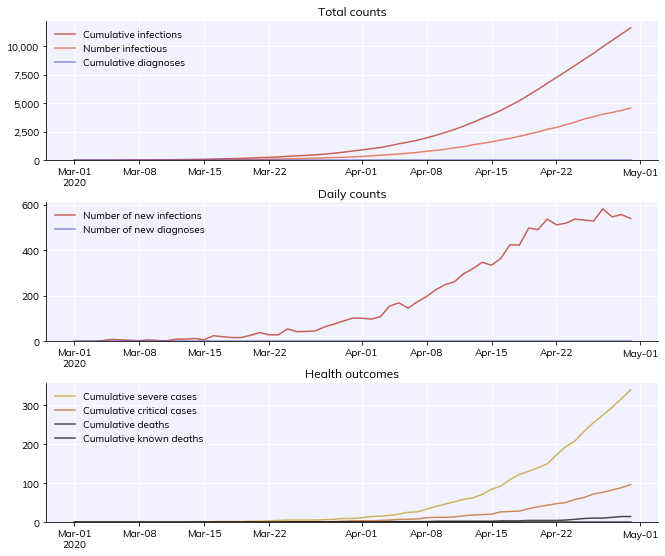

In [3]:
sim = cv.Sim(verbose=0)
sim.run().plot();

## One-dimensional sweep over beta

In [5]:
betas = np.logspace(-2.25, -1.25, 100)
sims = []
for i, beta in enumerate(betas):
    sim = cv.Sim(beta=beta, rand_seed=i, label=f'Beta = {beta}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days


Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 days

  Running "Beta = 0.005623413251903491": 2020-03-01 ( 0/60) (0.10 s)  ———————————————————— 2%
  Running "Beta = 0.006465558724388368": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.0060298017058345935": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.0091647624407065": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.00854708812559251": 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%

  Running "Beta = 0.006932806692144524": 2020-03-01 ( 0/60) (

MultiSim("Beta = 0.005623413251903491"; n_sims: 100; base: Sim("Beta = 0.005623413251903491"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

,log_beta,cum_inf
0,-2.250000,290.0
1,-2.239899,215.0
2,-2.229798,367.0
3,-2.219697,53.0
4,-2.209596,113.0
...,...,...
95,-1.290404,28676.0
96,-1.280303,29965.0
97,-1.270202,30126.0
98,-1.260101,29989.0


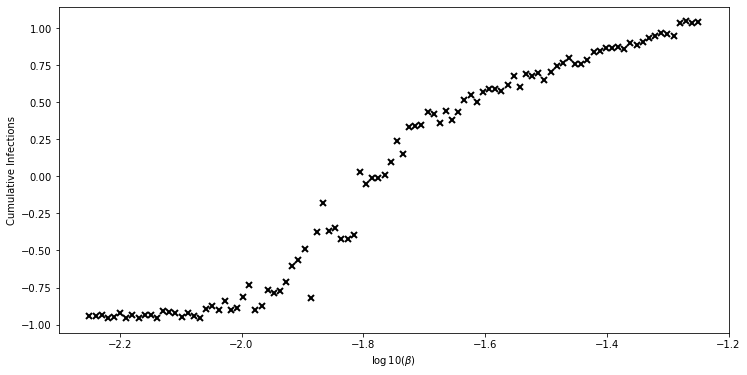

In [10]:
X = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X, 'cum_inf': Y})
display(df)
df.to_csv('beta_sweep.csv')

#X = np.array(np.log10([s.pars['beta'] for s in msim.sims])).reshape(-1, 1)
#Y = np.array([s.results['cum_infections'][-1] for s in msim.sims]).reshape(-1, 1)

Y = Y-Y.mean()
Y = 2 * Y / (Y.max() - Y.min())

f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');

In [6]:
k = gpf.kernels.Matern52()
print_summary(k)

╒═══════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                  │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═══════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ Matern52.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
├───────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ Matern52.lengthscales │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
╘═══════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧═════════╛


In [7]:
m = gpf.models.GPR(data=(X, Y), kernel=k, mean_function=None)
m.likelihood.variance.assign(1)
m.kernel.lengthscales.assign(0.3)
m.kernel.variance.assign(1)
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     1   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     0.3 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │     1   │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

In [8]:
opt = gpf.optimizers.Scipy()

opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)

2022-04-01 14:54:07.650172: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.801043   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.523163   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 0.00441548 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════

2022-04-01 14:54:08.416785: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


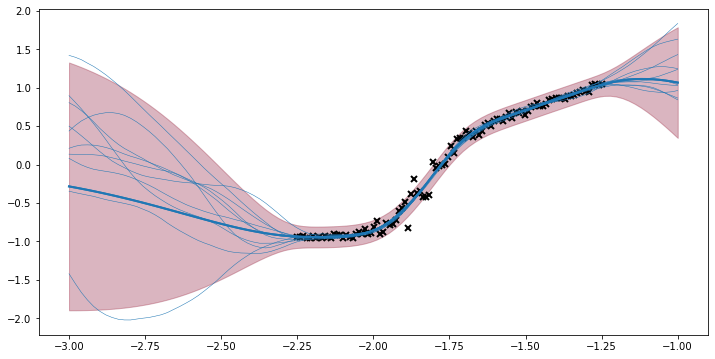

In [9]:
## generate test points for prediction
#xx = np.linspace(-0.1, 1.1, 100).reshape(100, 1)  # test points must be of shape (N, D)
xx = np.log10(np.logspace(-3, -1, 100)).reshape(100, 1).astype(dtyp)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean_f, var_f = m.predict_y(xx)
mean_y, var_y = m.predict_y(xx)

## generate 10 samples from posterior
tf.random.set_seed(1)  # for reproducibility
samples = m.predict_f_samples(xx, 10)  # shape (10, 100, 1)

## plot
plt.figure(figsize=(12, 6))
plt.plot(X, Y, "kx", mew=2)
def plot(mu, sig, col):
    plt.plot(xx, mu, "C0", lw=2)
    plt.fill_between(
        xx[:, 0],
        mu[:, 0] - 1.96 * np.sqrt(sig[:, 0]),
        mu[:, 0] + 1.96 * np.sqrt(sig[:, 0]),
        color=col,
        alpha=0.2,
    )
plot(mean_f, var_f, 'C0')
plot(mean_y, var_y, 'r')

plt.plot(xx, samples[:, :, 0].numpy().T, "C0", linewidth=0.5);
#_ = plt.xlim(-0.1, 1.1)

In [10]:
likelihood = gpf.likelihoods.HeteroskedasticTFPConditional(
    distribution_class=tfp.distributions.Normal,  # Gaussian Likelihood
    scale_transform=tfp.bijectors.Exp(),  # Exponential Transform
)

print(f"Likelihood's expected latent_dim: {likelihood.latent_dim}")

Likelihood's expected latent_dim: 2


In [11]:
def plot_distribution(X, Y, loc, scale):
    plt.figure(figsize=(15, 5))
    x = X.squeeze()
    for k in (1, 2):
        lb = (loc - k * scale).squeeze()
        ub = (loc + k * scale).squeeze()
        plt.fill_between(x, lb, ub, color="silver", alpha=1 - 0.05 * k ** 3)
    plt.plot(x, lb, color="silver")
    plt.plot(x, ub, color="silver")
    plt.plot(X, loc, color="black")
    plt.scatter(X, Y, color="gray", alpha=0.8)
    plt.show()
    plt.close()

In [12]:
kernel = gpf.kernels.SeparateIndependent(
    [
        gpf.kernels.SquaredExponential(),  # This is k1, the kernel of f1
        gpf.kernels.SquaredExponential(),  # this is k2, the kernel of f2
    ]
)
# The number of kernels contained in gpf.kernels.SeparateIndependent must be the same as likelihood.latent_dim

In [13]:
M = 25  # Number of inducing variables for each f_i

# Initial inducing points position Z
Z = np.linspace(X.min(), X.max(), M)[:, None]  # Z must be of shape [M, 1]
inducing_variable = gpf.inducing_variables.SeparateIndependentInducingVariables(
    [
        gpf.inducing_variables.InducingPoints(Z),  # This is U1 = f1(Z1)
        gpf.inducing_variables.InducingPoints(Z),  # This is U2 = f2(Z2)
    ]
)

name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,(),float64,1.0
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.25...
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.25...
SVGP.q_mu,Parameter,Identity,,True,"(25, 2)",float64,"[[0., 0...."
SVGP.q_sqrt,Parameter,FillTriangular,,True,"(2, 25, 25)",float64,"[[[1., 0., 0...."


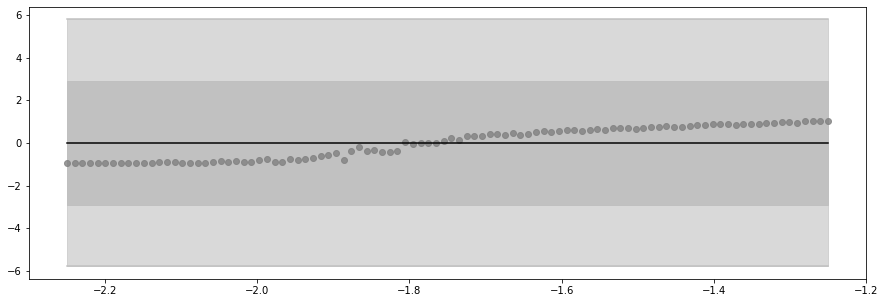

In [14]:
model = gpf.models.SVGP(
    kernel=kernel,
    likelihood=likelihood,
    inducing_variable=inducing_variable,
    num_latent_gps=likelihood.latent_dim,
)
'''

model = gpf.models.VGP(
    data=(X,Y),
    kernel=kernel,
    likelihood=likelihood,
    num_latent_gps=likelihood.latent_dim,
)
'''

#model.kernel.kernels[0].lengthscales.assign(1e6)
#model.kernel.kernels[0].variance.assign(1)
#model.kernel.kernels[1].lengthscales.assign(0.0002)
#model.kernel.kernels[1].variance.assign(10)

display(model)

'''
from gpflow.optimizers import NaturalGradient
from gpflow import set_trainable
from gpflow.ci_utils import ci_niter
natgrad = NaturalGradient(gamma=1.0)
adam = tf.optimizers.Adam()

set_trainable(model.q_mu, False)
set_trainable(model.q_sqrt, False)

for _ in range(ci_niter(1000)):
    natgrad.minimize(model.training_loss, [(model.q_mu, model.q_sqrt)])
    adam.minimize(model.training_loss, model.trainable_variables)
'''

Ymean, Yvar = model.predict_y(Xnew=X)#, full_cov=False)
Ymean = Ymean.numpy().squeeze()
Ystd = tf.sqrt(Yvar).numpy().squeeze()
plot_distribution(X, Y, Ymean, Ystd)

In [15]:
data = (X, Y)
loss_fn = model.training_loss_closure(data)

gpf.utilities.set_trainable(model.q_mu, False)
gpf.utilities.set_trainable(model.q_sqrt, False)

variational_vars = [(model.q_mu, model.q_sqrt)]
natgrad_opt = gpf.optimizers.NaturalGradient(gamma=0.1)

adam_vars = model.trainable_variables
adam_opt = tf.optimizers.Adam(0.01)


@tf.function
def optimisation_step():
    #with tf.device('CPU:0'):
    natgrad_opt.minimize(loss_fn, variational_vars)
    adam_opt.minimize(loss_fn, adam_vars)

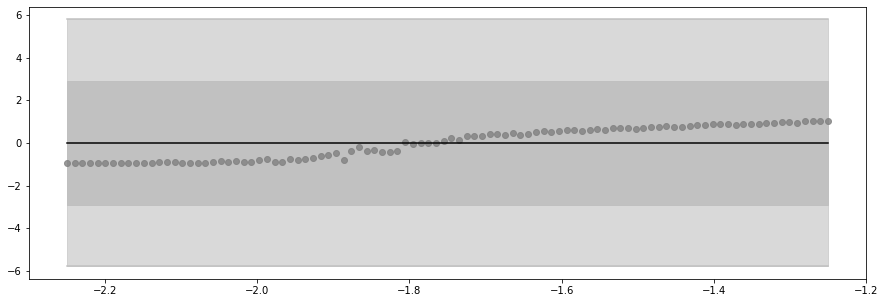

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: invalid value for "node": expected "ast.AST", got "<class 'NoneType'>"; to visit lists of nodes, use "visit_block" instead
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: invalid value for "node": expected "ast.AST", got "<class 'NoneType'>"; to visit lists of nodes, use "visit_block" instead
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Instructions for updating:
Use fn_output_signature instead
Epoch 1000 - Loss: -109.4277


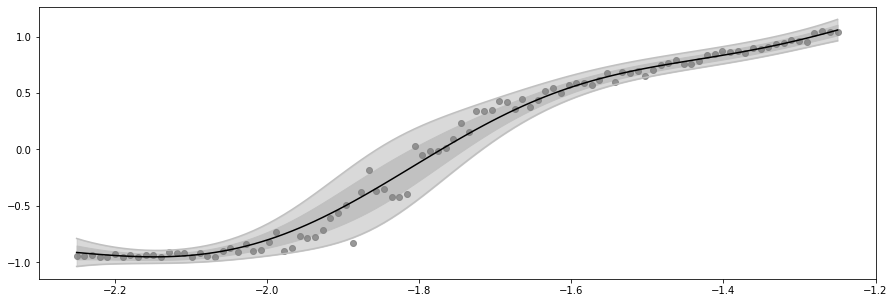

Epoch 2000 - Loss: -124.1409


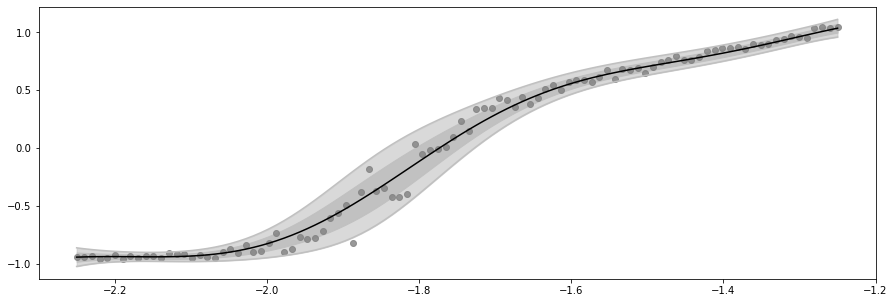

Epoch 3000 - Loss: -135.1048


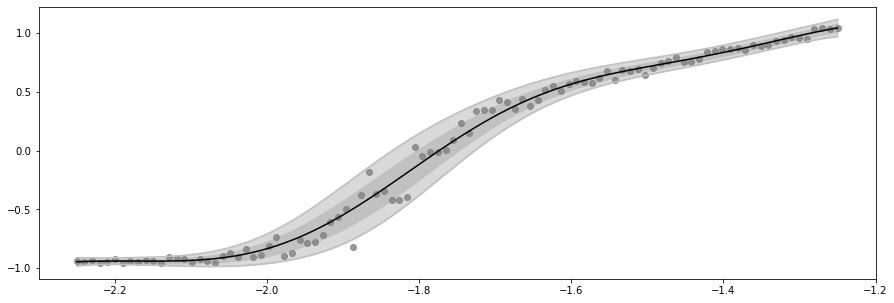

Epoch 4000 - Loss: -134.5838


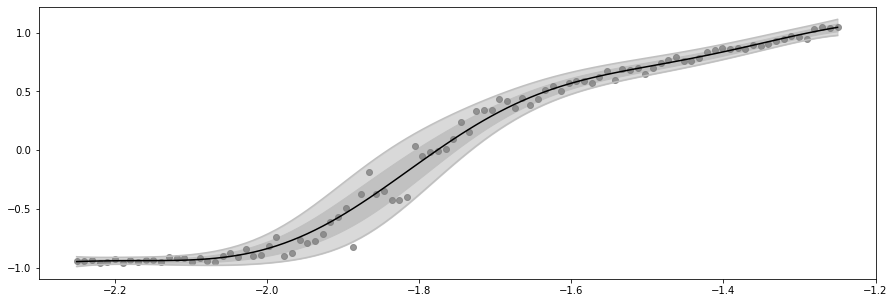

Epoch 5000 - Loss: -135.9936


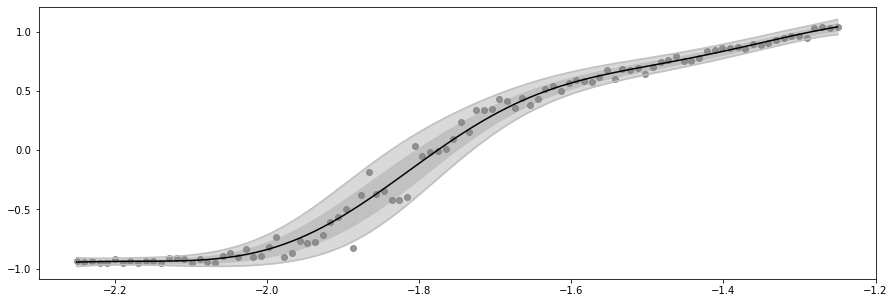

Epoch 6000 - Loss: -137.5335


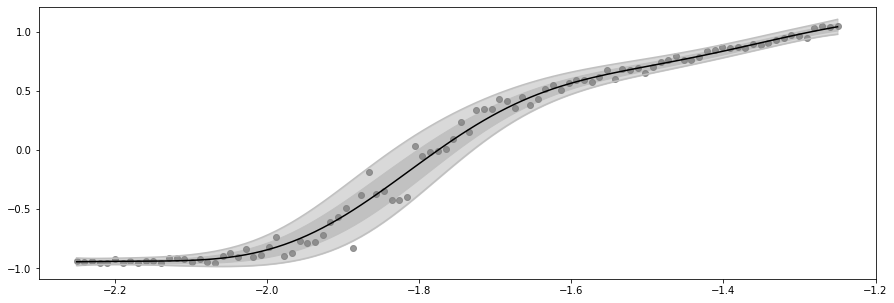

Epoch 7000 - Loss: -139.2337


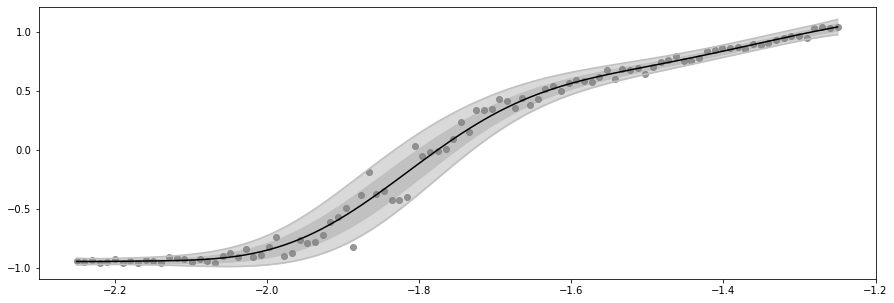

Epoch 8000 - Loss: -141.2915


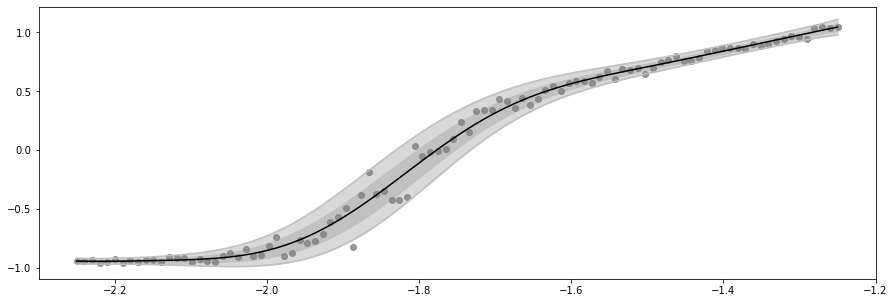

Epoch 9000 - Loss: -140.7010


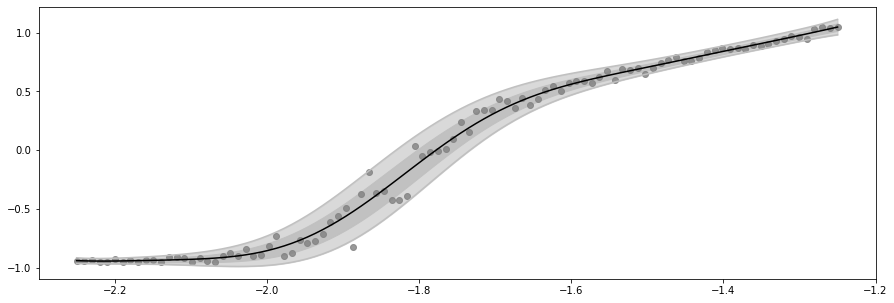

Epoch 10000 - Loss: -141.2136


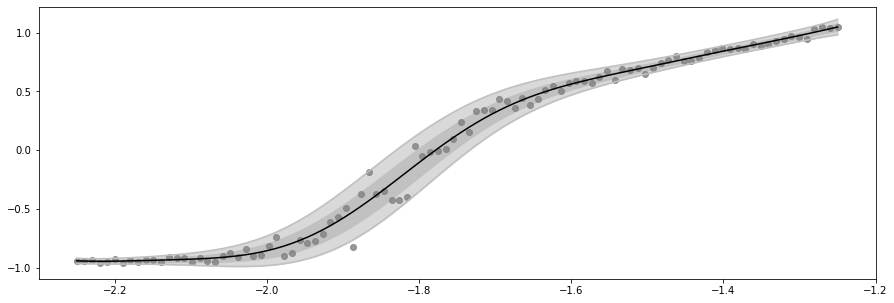

name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.7163252302517567
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,0.22701747422989813
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,27.27012118162919
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,(),float64,0.36858760944095315
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.2339006...
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.87291431...
SVGP.q_mu,Parameter,Identity,,False,"(25, 2)",float64,"[[-1.11412476, -0.0500006..."
SVGP.q_sqrt,Parameter,FillTriangular,,False,"(2, 25, 25)",float64,"[[[4.48009569e-03, 0.00000000e+00, 0.00000000e+00..."


In [16]:
epochs = 10000 # 100
log_freq = 1000 # 20

def p():
    Ymean, Yvar = model.predict_y(X)
    Ymean = Ymean.numpy().squeeze()
    Ystd = tf.sqrt(Yvar).numpy().squeeze()
    plot_distribution(X, Y, Ymean, Ystd)

p()
for epoch in range(1, epochs + 1):
    optimisation_step()

    # For every 'log_freq' epochs, print the epoch and plot the predictions against the data
    if epoch % log_freq == 0 and epoch > 0:
        print(f"Epoch {epoch} - Loss: {loss_fn().numpy() : .4f}")
        p()

model